<h1><center>SMS Spam Detection<h1><center>

In this project I am gonna be building a SMS/Email spam detection which classifies text into 2 categories:
* Spam (advertisements, scams and promotions)
* Ham (normal, day to day messages). The dataset has been taken from <a href ="https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset"> Kaggle </a>.
  

In [82]:
import numpy as np
import pandas as pd

In [83]:
df = pd.read_csv('spam.csv', encoding='iso-8859-1')

In [84]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3477,ham,I can ask around but there's not a lot in term...,NaN,NaN,NaN
1173,ham,ÌÏ dun need to pick ur gf?,NaN,NaN,NaN
4071,spam,Loans for any purpose even if you have Bad Cre...,NaN,NaN,NaN
5194,ham,Ok... Take ur time n enjoy ur dinner...,NaN,NaN,NaN
585,ham,Tell them u have a headache and just want to u...,NaN,NaN,NaN


In [85]:
df.shape

(5572, 5)

## <center> 1. Data Cleaning <center>

Data cleaning helps us to remove errors, duplicated and unecessary information form the dataset so the data becomes reliable and easy for analysis and modelling.

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [87]:
# droping the last three columns as their is no need for them in our data
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True) 

In [88]:
df.sample(5)

,v1,v2
5534,ham,Ok which your another number
1903,spam,Free entry in 2 a weekly comp for a chance to ...
3691,ham,No i am not having not any movies in my laptop
1135,ham,K do I need a login or anything
1514,ham,K:)all the best:)congrats...


In [89]:
# renaming the colummns names
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
2786,ham,cThen i thk shd b enuff.. Still got conclusion...
3893,spam,Dear Dave this is your final notice to collect...
3970,spam,Free video camera phones with Half Price line ...
1698,spam,"Free msg. Sorry, a service you ordered from 81..."
2830,ham,Thanx 4 sending me home...


In [90]:
# the code below helps us to transfrom ham to 0 and spam to 1 
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [91]:
df['target'] = encoder.fit_transform(df['target'])

In [92]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [93]:
# The code checks for a missing value, which was none in my case
df.isnull().sum()

target    0
text      0
dtype: int64

In [94]:
# The code checks if there are duplicate values
df.duplicated().sum()

np.int64(403)

In [95]:
# The code drops the duplicate value
df = df.drop_duplicates(keep='first')

In [96]:
df.duplicated().sum()

np.int64(0)

In [97]:
df.shape

(5169, 2)

## <center>2.EDA<center>

EDA is the process to analyze and visualize the dataset to understand patterns, realtionships before building the model.

In [98]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [99]:
# There are 4516 ham mesages and 653 spam messages in our dataset 
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

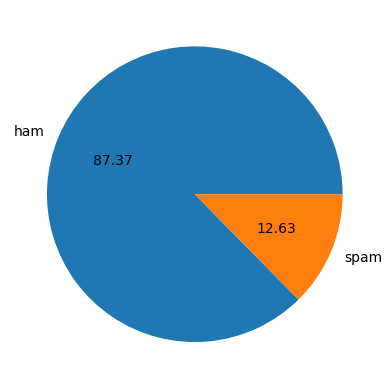

In [100]:
# A pie chart to see the imbalance b/w ham and spam
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [101]:
# Data is imbalanced as ham is more than spam

In [102]:
# Downloading the libraries
!pip install nltk
!pip install xgboost
import nltk

In [103]:
nltk.download('punkt_tab')
from nltk.corpus import stopwords #This helps us to remove the stopwords means the words that help in sentence formation but doesn't hold a significance in the sentence
import string
from nltk.stem.porter import PorterStemmer # This would help us to stem the words, discussed later
ps = PorterStemmer()
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\silwa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\silwa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [104]:
# Making column on num_characters
df['num_characters'] = df['text'].apply(len)

In [105]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [106]:
# Making column for number of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [107]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [108]:
# The code below split the sms into small sentences by the help of nltk library
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [109]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [110]:
# The code gives an idea about the data for each of the columns
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [111]:
# The code below shows every description for ham sms
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [112]:
## The code below shows every description for spam sms
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [113]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

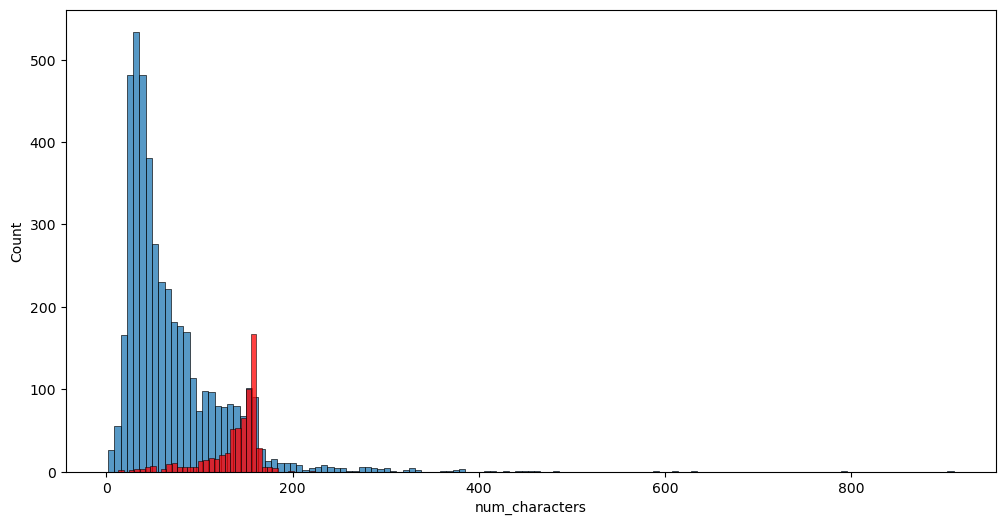

In [114]:
# The code below shows histoplot for ham(blue) and spam(red) on the number of characters
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

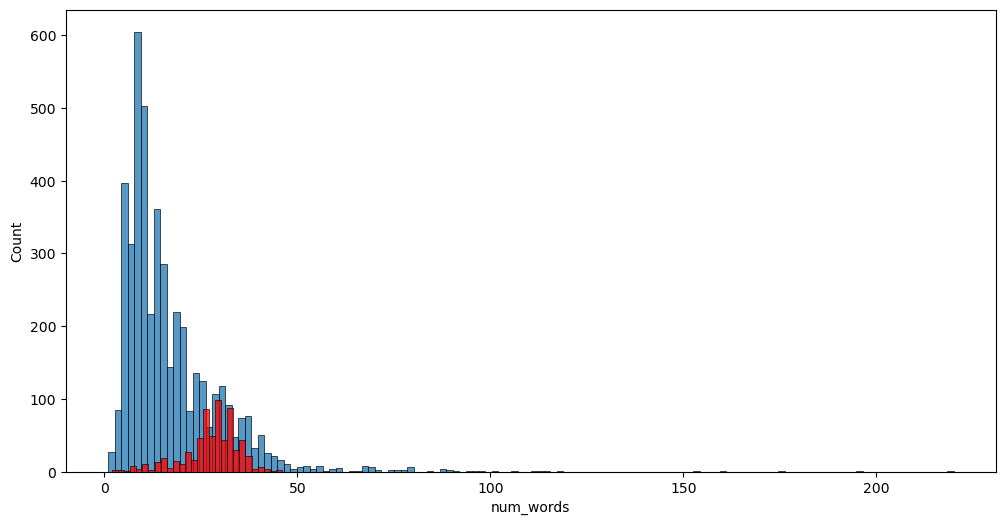

In [115]:
# The code below shows histoplot for ham(blue) and spam(red) on the number of words
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

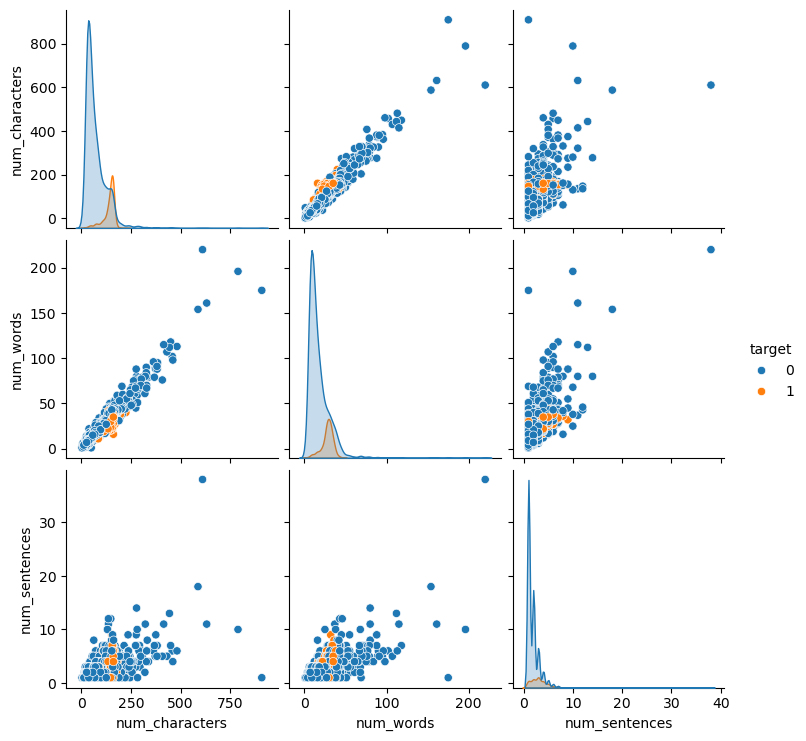

In [116]:
# Pairplot for every column on target
sns.pairplot(df,hue='target')

<Axes: >

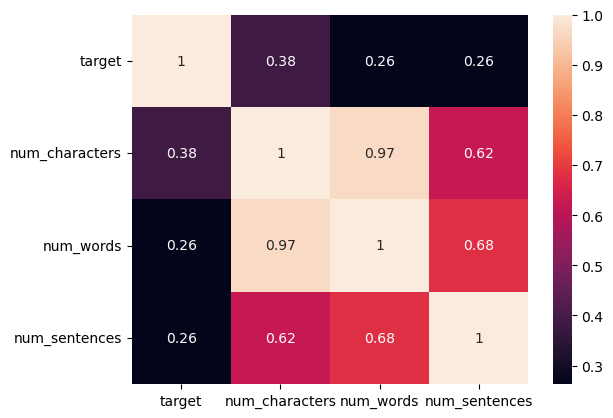

In [117]:
# A heatmap to see the correlation 
sns.heatmap(df.corr(numeric_only=True), annot=True)

## <center> 3. Data Preprocessing<center>
- Lower case (lower casing all the characters)
- Tokenization (breaking sentences into words)
- Removing special characters 
- Removing stop words and punctuation (removing words that are used for sentence formation and punctuation)
- Stemming (breaking different words into one ex dancing,dance and danced gets trimmed to dance)

In [118]:
# Function to do all the data Preprocessing
def transform_text(text):
    text = text.lower() # Makes the text lower case
    text = nltk.word_tokenize(text) 
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation: #This check for words that are not punction and not stopwords
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i)) # Really important to remove words that means the same thing
    
            
    return " ".join(y)

In [119]:
# Applying the method to every single column to create a new column with texts transformed
df['transformed_text'] = df['text'].apply(transform_text)

In [120]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [121]:
!pip install wordcloud # Wordcloud helps us to visualize most frequent words
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [122]:
# Word cloud for spam messages
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

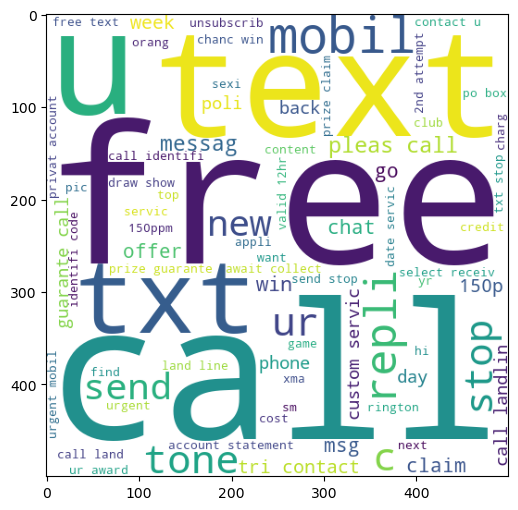

In [123]:
# The figure below shows the most common words of a spam message
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [124]:
# Wordcloud for ham messages
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

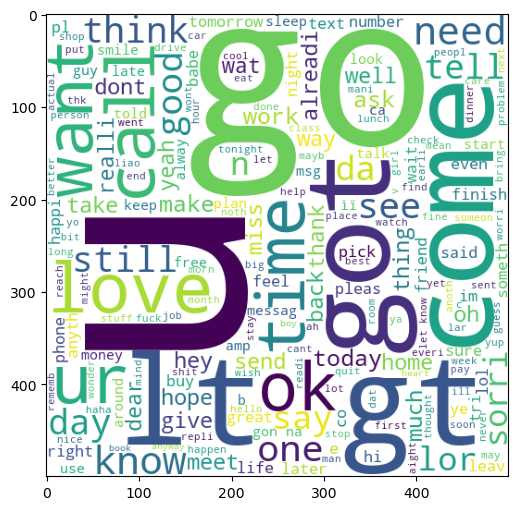

In [125]:
# The figure below shows the most common words for a genuine or ham messages
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [126]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [127]:
# The spam corpus holds the spam words
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [128]:
len(spam_corpus)

9939

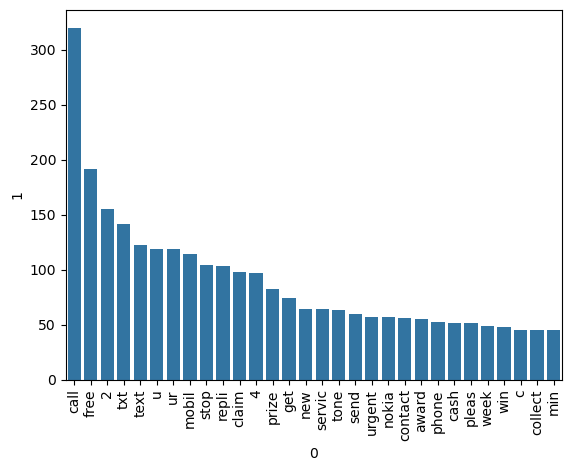

In [129]:
## The figure below shows the 30 most common words used for a spam message
from collections import Counter
sns.barplot(
    x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0], 
    y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()

In [130]:
# The ham corpus stores the ham words
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [131]:
len(ham_corpus)

35404

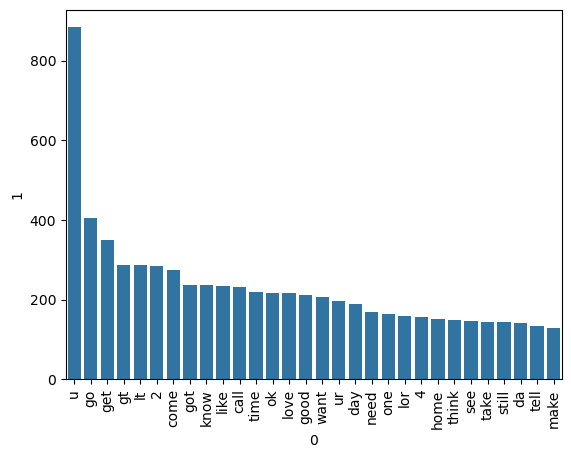

In [132]:
# The figure below shows the 30 most common words used for a geniune message
from collections import Counter
sns.barplot(
    x=pd.DataFrame(Counter(ham_corpus).most_common(30))[0], 
    y=pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
)
plt.xticks(rotation='vertical')
plt.show()

## <center>4. Model Building</center>

Model building is the process to train a train machine learning algorithm to catogorize messages as spam and ham

In [133]:
# I imported CountVectorizer and Tfidf and first test it on bag of words and it didn't gave a good precision so 
# end for going for Tfidf
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [134]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [135]:
X.shape

(5169, 3000)

In [136]:
y = df['target'].values

In [137]:
from sklearn.model_selection import train_test_split

In [138]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [139]:
# Improted the three algo's in Naive Bayes faminly, and also imported accuracy, presion to test upon and confusion matrix to evaluate the performance
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [140]:
# Assigning variables to each algo
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [141]:
# Training on GaussianNB, gives us a very poor acuracy and result
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [142]:
# Traning on MultinomialNB, gives a really good accuracy and an exact precision
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [143]:
# Training on Bernoulli, gives us a really good precision and accuracy. It classified one normal message as spam 
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [144]:
# Imprted different ml algorithms to check which one give me the best accuracy and presicion
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [145]:
# Assigning variable to each algo
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
bnb = BernoulliNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [146]:
# Inserting them into a dictionary to loop 
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': bnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [147]:
# This function test accuracy and precision for every ml algorithm
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9835589941972921
Precision -  0.991869918699187
For  DT
Accuracy -  0.9303675048355899
Precision -  0.8367346938775511
For  LR
Accuracy -  0.9584139264990329
Precision -  0.9702970297029703
For  RF
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8488372093023255
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [ ]:
# Gives us a dataframe that shows algorithms with highest scores
performance_df

After evaluating accuracy and precision for each model I decided to go with my first choice Naive Bayes, as it provides me high accuracy then K-Nearest Neighbours.

In [ ]:
# Lastly I pickled my model and tfidf so I could create an website on Streamlit
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(bnb,open('model.pkl','wb'))